# Lab 3: Forward Kinematics Using Robotics Toolbox

**Course:** 24AM3510 - Foundations of Robotics and Intelligent Systems  
**Mapped course outcome:** CO2  
**Lab focus:** Forward kinematics using Peter Corke's Robotics Toolbox for Python  
**Suggested duration:** 60 minutes + independent assignment

## Purpose

In Lectures 15, you studied **forward kinematics** as the mapping

$$\mathbf q \longrightarrow 	ext{end-effector pose}$$

and worked through the planar 2R model.

In Labs 1 and 2, you learned how to:

- visualise robot configurations,
- create and interpret coordinate frames,
- compose poses,
- transform points between frames, and
- use the Spatial Math objects provided by the toolbox.

This lab is the next step: **use the Robotics Toolbox to perform forward kinematics and interpret the resulting end-effector pose.**

The emphasis is not on deriving matrices again. The emphasis is on learning the toolbox workflow:

**robot model → joint configuration → `fkine()` → end-effector pose → interpretation → visualisation**

> **Important:** You should be able to explain what the toolbox is calculating even when the calculation itself is performed by an API.


## Learning objectives

By the end of this lab, you should be able to:

1. Create/load a robot model in Robotics Toolbox.
2. Represent a robot configuration as a joint-value vector.
3. Use `robot.fkine(q)` to compute the end-effector pose.
4. Extract end-effector position and orientation from the returned pose.
5. Visualise the same joint configuration using `robot.plot(q)`.
6. Compare toolbox output with the planar 2R forward-kinematic equations from the lecture.
7. Change joint values and predict how the end-effector pose will change.
8. Explain the difference between **joint space** and **task space** in the context of FK.

## Prerequisite

Before starting this lab, you should understand:

- revolute joint variables $(q_1,q_2,\ldots),$
- robot configuration,
- coordinate frames,
- homogeneous transformations,
- the 2R planar forward-kinematic equations.

You do **not** need to derive the transformation matrix again in this notebook.


## Toolbox vocabulary for this lab

| API / object | Purpose |
|---|---|
| `rtb.models.DH.Puma560()` | Load the built-in PUMA 560 robot model |
| `robot.plot(q)` | Visualise the robot at joint configuration `q` |
| `robot.fkine(q)` | Compute the end-effector pose for configuration `q` |
| `T.t` | Extract the translation / position from a pose `T` |
| `T.R` | Extract the rotation matrix from a pose `T` |
| `T.rpy(...)` | Obtain an orientation representation such as roll-pitch-yaw |
| `robot.qz` | Named zero configuration for the built-in PUMA model |
| `robot.qr` | Named ready configuration for the built-in PUMA model |

The important conceptual distinction is:

- **`q`** describes the robot in **joint space**.
- **`T = robot.fkine(q)`** describes the end-effector in **task space / pose space**.

The toolbox performs the transformation calculation; your job is to understand and interpret the result.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

np.set_printoptions(precision=4, suppress=True)

print("Robotics Toolbox version:", rtb.__version__)
print("Environment ready.")


Robotics Toolbox version: 1.4.2
Environment ready.


# Experiment 1 - Load and visualise a robot

## API: `rtb.models.DH.Puma560()`

In Lab 1 you used the same built-in PUMA model for robot visualisation.

Here we continue from that point.

The important idea is that a robot model contains its kinematic structure. Once the model exists, a joint configuration `q` tells the toolbox **how the robot is currently configured**.

## API: `robot.plot(q)`

`robot.plot(q)` visualises the robot for the supplied joint configuration.

Run the following cell and identify:

1. the robot base,
2. the individual joints,
3. the end-effector,
4. the joint configuration being displayed.


Number of joints: 6
Zero configuration qz: [0. 0. 0. 0. 0. 0.]


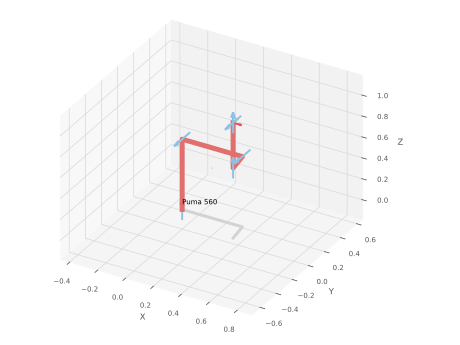

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'Puma 560')

In [2]:
robot = rtb.models.DH.Puma560()

q = robot.qz

print("Number of joints:", robot.n)
print("Zero configuration qz:", q)

robot.plot(q, backend='pyplot', block=False)


### Checkpoint 1

Look at the value of `q`.

**Question:** If the robot has 6 joints, why does `q` contain 6 values?

Now change one element of `q` and plot the robot again.

Before running the code, predict which part of the robot will move.


Modified configuration: [0.5236 0.     0.     0.     0.     0.    ]


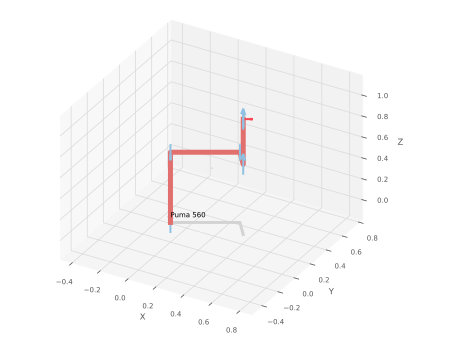

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'Puma 560')

In [3]:
q_test = q.copy()
q_test[0] = np.deg2rad(30)

print("Modified configuration:", q_test)

robot.plot(q_test, backend='pyplot', block=False)


# Experiment 2 - What does forward kinematics return?

## API: `robot.fkine(q)`

The central API in this lab is:

```python
T = robot.fkine(q)
```

It implements the forward-kinematic mapping:

$$
\mathbf q \longrightarrow {}^{W}T_E
$$

where:

- `q` = robot joint configuration,
- `T` = end-effector pose with respect to the robot/world base frame.

The returned object is a Spatial Math pose object.

Run the cell and inspect `T`.


In [4]:
q = robot.qz

T = robot.fkine(q)

print("Joint configuration q:")
print(q)

print("\nEnd-effector pose T:")
print(T)


Joint configuration q:
[0. 0. 0. 0. 0. 0.]

End-effector pose T:
   1         0         0         0.4521    
   0         1         0        -0.15      
   0         0         1         1.104     
   0         0         0         1         



### Interpret the result

Do not treat the output as an unexplained 4×4 matrix.

For a homogeneous transformation,

\[
T =
egin{bmatrix}
R & p \
0 & 1
\end{bmatrix}
\]

where:

- \(R\) describes orientation,
- \(p=[x\ y\ z]^T\) describes position.

Therefore, `fkine(q)` gives you both:

**position + orientation**

of the end-effector for the supplied joint configuration.


# Experiment 3 - Extract end-effector position

## API: `T.t`

The position of the end-effector can be obtained using:

```python
T.t
```

This returns the translation component of the pose.

For a 3D robot:

$$
p =
\begin{bmatrix}
x\\y\\z
\end{bmatrix}
$$

Run the cell and identify the end-effector's x, y and z coordinates.


In [5]:
position = T.t

print("End-effector position [x, y, z]:")
print(position)


End-effector position [x, y, z]:
[ 0.4521 -0.15    1.1036]


### Think before you run

Suppose one joint angle changes.

Would you expect:

- only the end-effector orientation to change?
- only the position to change?
- both position and orientation to potentially change?

Explain your prediction in one or two sentences.

Then test it by changing one joint variable and recomputing FK.


In [6]:
q2 = q.copy()
q2[1] = np.deg2rad(30)

T2 = robot.fkine(q2)

print("Original position:")
print(T.t)

print("\nNew position:")
print(T2.t)

print("\nPosition change:")
print(T2.t - T.t)


Original position:
[ 0.4521 -0.15    1.1036]

New position:
[ 0.1756 -0.15    1.2718]

Position change:
[-0.2765  0.      0.1682]


# Experiment 4 - Extract end-effector orientation

## API: `T.R`

The rotation component can be obtained using:

```python
T.R
```

This gives the 3×3 rotation matrix associated with the end-effector orientation.

This connects directly to the rotation matrices studied in Lecture 9 and the homogeneous transformation matrix studied in Lectures 10–11.

Run the cell.


In [7]:
R = T.R

print("End-effector rotation matrix:")
print(R)


End-effector rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Optional orientation representation: `T.rpy()`

A rotation matrix is mathematically useful, but it is not always the easiest representation to interpret.

The toolbox can also provide roll-pitch-yaw angles:

```python
T.rpy(unit='deg')
```

For this foundations lab, focus on understanding that this is **another representation of orientation**. Do not treat RPY as a different physical orientation.

Run the cell and inspect the result.


In [8]:
rpy = T.rpy(unit='deg')

print("End-effector orientation [roll, pitch, yaw] in degrees:")
print(rpy)


End-effector orientation [roll, pitch, yaw] in degrees:
[ 0. -0.  0.]


# Experiment 5 - Forward kinematics and visualisation together

So far we have calculated a pose numerically.

Now connect the numerical result to the robot you can see.

The workflow is:

$$
\boxed{\mathbf q}

\rightarrow
\boxed{	robot.fkine(q)}

\rightarrow
\boxed{T_E}
$$

and

$$
\boxed{\mathbf q}

\rightarrow
\boxed{	exttt{robot.plot(q)}}
$$

The two operations answer different questions:

- `fkine(q)` → **Where is the end-effector?**
- `plot(q)` → **What does the robot configuration look like?**

Run the following example.


Joint configuration in degrees:
[  0. -30.  30.   0.  45.   0.]

End-effector position:
[ 0.3942 -0.15    0.8877]

End-effector rotation matrix:
[[ 0.7071 -0.     -0.7071]
 [ 0.      1.     -0.    ]
 [ 0.7071 -0.      0.7071]]


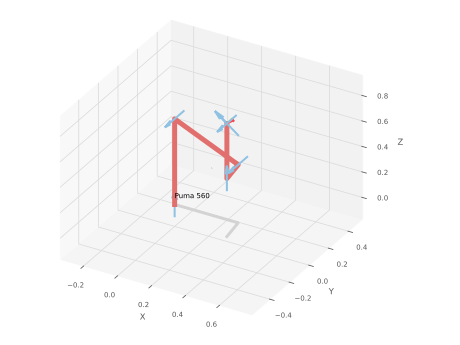

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'Puma 560')

In [9]:
q = np.array([0, -30, 30, 0, 45, 0], dtype=float)
q = np.deg2rad(q)

T = robot.fkine(q)

print("Joint configuration in degrees:")
print(np.rad2deg(q))

print("\nEnd-effector position:")
print(T.t)

print("\nEnd-effector rotation matrix:")
print(T.R)

robot.plot(q, backend='pyplot', block=False)


### Checkpoint 2

Answer before changing the code:

1. Which values belong to joint space?
2. Which values describe the end-effector pose?
3. Which API performs the forward-kinematic calculation?
4. Which API visualises the robot?

Now change `q[0]` by +20 degrees and run the cell again.

Observe both the robot motion and the change in end-effector pose.


# Experiment 6 - A 2R planar manipulator

The lecture derivation used a 2R planar robot:

$$
\mathbf q =
\begin{bmatrix}
q_1\q_2
\end{bmatrix}
$$

with link lengths $(a_1\) and (a_2)$

For this robot:

\[
x=a_1\cos q_1+a_2\cos(q_1+q_2)
\]

\[
y=a_1\sin q_1+a_2\sin(q_1+q_2)
\]

\[
	heta_E=q_1+q_2
\]

The purpose of this experiment is to connect the **equations you derived in class** with the **Robotics Toolbox result**.

> We will use the toolbox's planar 2R model. You do not need to derive or modify its internal DH parameters in this lab. Treat the robot model as the kinematic object supplied to the toolbox.


In [ ]:
planar2 = rtb.models.DH.Planar2()

print(planar2)


## Choose a joint configuration

Use:

- \(q_1 = 30^\circ\)
- \(q_2 = 60^\circ\)

First calculate the expected end-effector position from the lecture equations.

Then run the toolbox code.

**Do not simply copy the toolbox answer. Use the equations first.**


In [ ]:
q1 = np.deg2rad(30)
q2 = np.deg2rad(60)

q_planar = np.array([q1, q2])

T_planar = planar2.fkine(q_planar)

print("q =", np.rad2deg(q_planar))
print("\nToolbox pose:")
print(T_planar)

print("\nToolbox position [x, y, z]:")
print(T_planar.t)


### Compare theory and toolbox

For the planar 2R model, compare:

\[
x_{	ext{theory}}
\quad	ext{with}\quad
x_{	ext{toolbox}}
\]

and

\[
y_{	ext{theory}}
\quad	ext{with}\quad
y_{	ext{toolbox}}
\]

Write a short Markdown answer:

1. What values did you obtain from the lecture equations?
2. What values did the toolbox return?
3. Are they consistent?
4. If they are not consistent, what should you check first?

Typical checks include joint-angle units, model choice, joint ordering and the configuration supplied to `fkine()`.


# Experiment 7 - Change the configuration and observe FK

Forward kinematics is a function:

\[
f(\mathbf q)=T_E
\]

Changing the joint configuration changes the end-effector pose.

Choose three different configurations and observe the resulting positions.

For each configuration:

1. define `q`,
2. calculate `T = robot.fkine(q)`,
3. print `T.t`,
4. visualise the robot.

Try to predict the direction of motion before executing each configuration.


In [ ]:
configurations_deg = [
    [20, 40],
    [60, -30],
    [-30, 70]
]

for q_deg in configurations_deg:
    q = np.deg2rad(q_deg)
    T = planar2.fkine(q)

    print("q (deg):", q_deg)
    print("position [x, y, z]:", T.t)
    print("-" * 50)

    planar2.plot(q, backend='pyplot', block=False)


# Experiment 8 - A reusable FK function

A good robotics program should not repeat the same calculation manually.

Create a small function that accepts a robot and a joint configuration and returns the end-effector position.

Complete the code below.

**Your task:** replace `YOUR_CODE_HERE` with the appropriate toolbox API.


In [ ]:
def end_effector_position(robot, q):
    YOUR_CODE_HERE


# Test your function
q_test = np.deg2rad([30, 60])

position = end_effector_position(planar2, q_test)

print("End-effector position:")
print(position)


## Checkpoint 3 - Explain the function

In your own words, explain:

> Why does the function need the joint configuration `q`?

and

> Why can the same robot model produce different end-effector positions?

This is the key idea behind forward kinematics.


# Lab summary

You have now used the basic Robotics Toolbox workflow for forward kinematics.

### Core APIs

```python
robot = rtb.models.DH.Puma560()

T = robot.fkine(q)

position = T.t
rotation = T.R
orientation = T.rpy(unit='deg')

robot.plot(q)
```

### Conceptual workflow

\[
oxed{	ext{Joint configuration } \mathbf q}
\]

↓

\[
oxed{	exttt{robot.fkine(q)}}
\]

↓

\[
oxed{	ext{End-effector pose }T_E}
\]

↓

\[
oxed{	ext{Position + Orientation}}
\]

### Final checkpoint

Without looking back at the code, answer:

1. What is the input to forward kinematics?
2. What is the output?
3. Which API computes FK?
4. How do you obtain position from the returned pose?
5. How do you obtain orientation?
6. Which API visualises the robot configuration?
7. What is the relationship between joint space and task space?


# Assignment - Forward Kinematics Investigation

**Submission:** Within one week

**Important:** The assignment uses only APIs and concepts introduced in this lab. Do not use a different robotics library.

Keep the notebook outputs visible and write your explanations in Markdown cells.

## Problem 1 - 2R planar forward kinematics

Use the Robotics Toolbox planar 2R model.

Given:

- \(a_1 = 1\) m
- \(a_2 = 1\) m
- \(q_1 = 45^\circ\)
- \(q_2 = 30^\circ\)

### Tasks

1. Create the 2R robot model.
2. Define the joint configuration in radians.
3. Use `robot.fkine(q)` to calculate the end-effector pose.
4. Extract and report the end-effector position.
5. Calculate \(x\), \(y\), and \(	heta_E\) independently using the equations from the lecture.
6. Compare the analytical and toolbox results.
7. Plot the robot at this configuration.
8. In 3-4 sentences, explain why the toolbox result should agree with the analytical result.


In [ ]:
# Assignment Problem 1
# Write your solution here.


## Problem 2 - Configuration change and end-effector motion

Use the same 2R robot.

Compare these two configurations:

- Configuration A: \(q_1=20^\circ,\;q_2=40^\circ\)
- Configuration B: \(q_1=60^\circ,\;q_2=-20^\circ\)

### Tasks

1. Compute the FK pose for both configurations using `robot.fkine(q)`.
2. Report the end-effector position for each.
3. Report the end-effector orientation.
4. Plot both configurations.
5. Explain how changing the joint values changed the end-effector pose.
6. State whether the two configurations produce the same end-effector position. Support your answer with the computed values.


In [ ]:
# Assignment Problem 2
# Write your solution here.


## Problem 3 - 6-DOF industrial robot

Use the PUMA 560 model introduced in this lab.

Choose the following configuration:

\[
q=[20^\circ,-30^\circ,40^\circ,10^\circ,30^\circ,-20^\circ]
\]

### Tasks

1. Create the PUMA 560 model.
2. Convert the joint configuration to radians.
3. Compute the end-effector pose using `robot.fkine(q)`.
4. Extract and report:
   - end-effector position,
   - rotation matrix,
   - roll-pitch-yaw orientation.
5. Plot the robot.
6. Change only \(q_1\) by +20° and recompute the pose.
7. Compare the original and modified end-effector positions.
8. Explain why a small change in one joint can change more than one component of the end-effector pose.


In [ ]:
# Assignment Problem 3
# Write your solution here.


# Submission checklist

Before submitting:

- [ ] The notebook uses the Robotics Toolbox introduced in the lab.
- [ ] All cells execute without errors.
- [ ] Joint angles are converted to the correct units where required.
- [ ] `fkine()` is used for forward-kinematic computation.
- [ ] Position and orientation are extracted from the returned pose.
- [ ] Required robot plots are visible.
- [ ] Analytical 2R calculations are shown.
- [ ] Analytical and toolbox results are compared.
- [ ] Interpretation questions are answered in Markdown.
- [ ] No unexplained code has been copied from an external source or AI tool.
- [ ] If AI was used for debugging, record the error, the prompt/query used, and your explanation of the final fix.
- [ ] Notebook filename contains your name and USN.
